# Malware Detection Based on System Calls

Target: Score >= 5 = Malware (1),
Score < 5 = Benign (0)

## 1. Imports and Setup

In [42]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print('All libraries loaded successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries loaded successfully!
TensorFlow version: 2.21.0


## 2. Load Data and Drop Columns

In [43]:
df = pd.read_csv('Malware_Analysis.csv')
print(f'Original shape: {df.shape}')

columns_to_drop = [
    'pid', 'info_id',
    #unique ids

    'API_GetAdaptersInfo', 'API_InternetSetStatusCallback',
    'API_SetFileInformationByHandle', 'API_getaddrinfo',
    'API_RtlDecompressBuffer', 'API_DnsQuery_A',
    'API_Module32NextW', 'API_ControlService',
    'API_JsGlobalObjectDefaultEvalHelper',
    'API_Thread32Next', 'API_Thread32First',
    #same value for every row

    'ttp_T1045_short', 'ttp_T1045_long',
    'ttp_T1082_short', 'ttp_T1082_long',
    'ttp_T1158_short', 'ttp_T1158_long',
    #mostly empty

    'description_y',
    'description_x', 'references'
    # unstructured text and url
]

df = df.drop(columns=columns_to_drop, errors='ignore')
print(f'Shape after dropping columns: {df.shape}')

Original shape: (1308, 395)
Shape after dropping columns: (1308, 373)


## 3. Create Target Label and Preprocess

In [ ]:
df['label'] = (df['Score'] >= 6.5).astype(int)
print('Class distribution:')
print(df['label'].value_counts())
print(f'Benign (0): {(df["label"]==0).sum()}')
print(f'Malware (1): {(df["label"]==1).sum()}')
df = df.drop(columns=['Score'])


SyntaxError: incomplete input (764386510.py, line 1)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le_dict = {}
for i in cat_cols:
    le = LabelEncoder()
    df[i] = df[i].fillna('missing')
    df[i] = le.fit_transform(df[i])
    le_dict[i] = le

df = df.fillna(0)
print(f'Final dataset shape: {df.shape}')
print(f'Any nulls remaining: {df.isnull().sum().sum()}')
df.head()

Categorical columns to encode: []
Final dataset shape: (1308, 373)
Any nulls remaining: 0


,API_CoInitializeEx,API_CoUninitialize,API_NtResumeThread,API_NtOpenFile,API_CoCreateInstance,API_CoInitializeSecurity,API_NtDelayExecution,API_NtCreateFile,API_NtAllocateVirtualMemory,API_LdrLoadDll,...,rule_spyeye,rule_suspicious_packer_section,rule_vmdetect,rule_win_asyncrat_j1,rule_win_files_operation,rule_win_mutex,rule_win_private_profile,rule_win_registry,rule_with_sqlite,label
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,7.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,1.0,0.0,0.0,14.0,22.0,22.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,56.0,55.0,0.0,0.0,135.0,0.0,3.0,2.0,41.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,64.0,2.0,37.0,3972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,55.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


## 4. Split 80/20

In [ ]:
X = df.drop(columns=['label'])
y = df['label']
feature_names = X.columns.tolist()
print(f'Number of features: {X.shape[1]}')
print(f'Number of samples:  {X.shape[0]}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set:  {X_test.shape[0]} samples')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Feature scaling complete.')

Number of features: 372
Number of samples:  1308
Train set: 1046 samples
Test set:  262 samples
Feature scaling complete.


## 5. Evaluation Helper

In [ ]:
results = {}

def evaluate_model(name, y_true, y_pred, train_time):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1,
        'Training Time (s)': round(train_time, 4),
        'y_pred': y_pred
    }
    print(f'\n{"="*50}')
    print(f'  {name} Results')
    print(f'{"="*50}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  Time:      {train_time:.4f}s')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malware']))

print('Ready.')

Ready.


## 6. Random Forest

In [ ]:
start = time.time()
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_time = time.time() - start
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_pred = (rf_prob >= 0.4130).astype(int)  # Optimal threshold from PR curve
evaluate_model('Random Forest', y_test, rf_pred, rf_time)

start = time.time()


  Random Forest Results
  Accuracy:  0.9046
  Precision: 0.8805
  Recall:    0.9589
  F1-Score:  0.9180
  Time:      0.2969s
              precision    recall  f1-score   support

      Benign       0.94      0.84      0.89       116
     Malware       0.88      0.96      0.92       146

    accuracy                           0.90       262
   macro avg       0.91      0.90      0.90       262
weighted avg       0.91      0.90      0.90       262



## 7. SVM

In [ ]:
start = time.time()
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_time = time.time() - start
svm_scores = svm_model.decision_function(X_test_scaled)
svm_pred = (svm_scores >= -0.3346).astype(int)  # Optimal threshold from ROC/PR curve
evaluate_model('SVM', y_test, svm_pred, svm_time)


  SVM Results
  Accuracy:  0.8931
  Precision: 0.8782
  Recall:    0.9384
  F1-Score:  0.9073
  Time:      0.1008s
              precision    recall  f1-score   support

      Benign       0.92      0.84      0.87       116
     Malware       0.88      0.94      0.91       146

    accuracy                           0.89       262
   macro avg       0.90      0.89      0.89       262
weighted avg       0.89      0.89      0.89       262



## 8. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5665).astype(int)  # Optimal threshold from ROC curve
evaluate_model('Logistic Regression', y_test, lr_pred, lr_time)


  Logistic Regression Results
  Accuracy:  0.8969
  Precision: 0.9281
  Recall:    0.8836
  F1-Score:  0.9053
  Time:      0.0720s
              precision    recall  f1-score   support

      Benign       0.86      0.91      0.89       116
     Malware       0.93      0.88      0.91       146

    accuracy                           0.90       262
   macro avg       0.89      0.90      0.90       262
weighted avg       0.90      0.90      0.90       262



## 9. Neural Network (MLP)

In [ ]:
from sklearn.neural_network import MLPClassifier
import time

start = time.time()
nn_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_time = time.time() - start
nn_prob = nn_model.predict_proba(X_test_scaled)[:, 1]
nn_pred = (nn_prob >= 0.7714).astype(int)  # Optimal threshold from ROC curve
evaluate_model('Neural Network', y_test, nn_pred, nn_time)


  Neural Network Results
  Accuracy:  0.9008
  Precision: 0.9286
  Recall:    0.8904
  F1-Score:  0.9091
  Time:      1.3541s
              precision    recall  f1-score   support

      Benign       0.87      0.91      0.89       116
     Malware       0.93      0.89      0.91       146

    accuracy                           0.90       262
   macro avg       0.90      0.90      0.90       262
weighted avg       0.90      0.90      0.90       262



## 10. 1D CNN

In [ ]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', padding='same', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Conv1D(128, 3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Conv1D(64, 3, activation='relu', padding='same'),
    BatchNormalization(), MaxPooling1D(2), Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'), Dropout(0.4),
    Dense(64, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

start = time.time()
history = cnn_model.fit(X_train_cnn, y_train, epochs=100, batch_size=32,
    validation_split=0.2, callbacks=[early_stop], verbose=1)
cnn_time = time.time() - start

cnn_prob = cnn_model.predict(X_test_cnn).flatten()
cnn_pred = (cnn_prob >= 0.3615).astype(int)  # Optimal threshold from PR curve
evaluate_model('1D CNN', y_test, cnn_pred, cnn_time)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 372, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 372, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 186, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 186, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 186, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 186, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 93, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 93, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 93, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 93, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,905 (1.66 MB)

 Trainable params: 435,393 (1.66 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6615 - loss: 0.7733 - val_accuracy: 0.6238 - val_loss: 0.6439
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7608 - loss: 0.5805 - val_accuracy: 0.5429 - val_loss: 0.7515
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8182 - loss: 0.4701 - val_accuracy: 0.5048 - val_loss: 0.9952
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8230 - loss: 0.5011 - val_accuracy: 0.5667 - val_loss: 0.9489
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8517 - loss: 0.4417 - val_accuracy: 0.5667 - val_loss: 1.0363
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8840 - loss: 0.3499 - val_accuracy: 0.5905 - val_loss: 0.9087
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8756 - loss: 0.3550 - val_accuracy: 0.6000 - val_loss: 0.8911
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9067 - loss: 0.2750 - val_accuracy: 0.

## 11. Ensemble (Majority Voting)


In [ ]:
from scipy.stats import mode
import time
import numpy as np

start = time.time()
# Combine predictions from all 5 models
all_preds = np.array([rf_pred, svm_pred, lr_pred, nn_pred, cnn_pred])
# Perform hard voting (majority vote)
ensemble_pred, _ = mode(all_preds, axis=0, keepdims=False)
ensemble_pred = ensemble_pred.flatten()
ensemble_time = time.time() - start
evaluate_model('Ensemble', y_test, ensemble_pred, ensemble_time)



  Ensemble Results
  Accuracy:  0.9160
  Precision: 0.9247
  Recall:    0.9247
  F1-Score:  0.9247
  Time:      0.0014s
              precision    recall  f1-score   support

      Benign       0.91      0.91      0.91       116
     Malware       0.92      0.92      0.92       146

    accuracy                           0.92       262
   macro avg       0.91      0.91      0.91       262
weighted avg       0.92      0.92      0.92       262



## 12. Model Comparison Table

In [ ]:
model_names = ['Random Forest', 'SVM', 'Logistic Regression', 'Neural Network', '1D CNN', 'Ensemble']
comparison_data = []
for name in model_names:
    r = results[name]
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{r['Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall': f"{r['Recall']:.4f}",
        'F1-Score': f"{r['F1-Score']:.4f}",
        'Time (s)': f"{r['Training Time (s)']:.4f}"
    })
comparison_df = pd.DataFrame(comparison_data)
print('MODEL COMPARISON SUMMARY')
print(comparison_df.to_string(index=False))

MODEL COMPARISON SUMMARY
              Model Accuracy Precision Recall F1-Score Time (s)
      Random Forest   0.9046    0.8805 0.9589   0.9180   0.2969
                SVM   0.8931    0.8782 0.9384   0.9073   0.1008
Logistic Regression   0.8969    0.9281 0.8836   0.9053   0.0720
     Neural Network   0.9008    0.9286 0.8904   0.9091   1.3541
             1D CNN   0.8893    0.8980 0.9041   0.9010  23.9951
           Ensemble   0.9160    0.9247 0.9247   0.9247   0.0014


## 13. Confusion Matrices

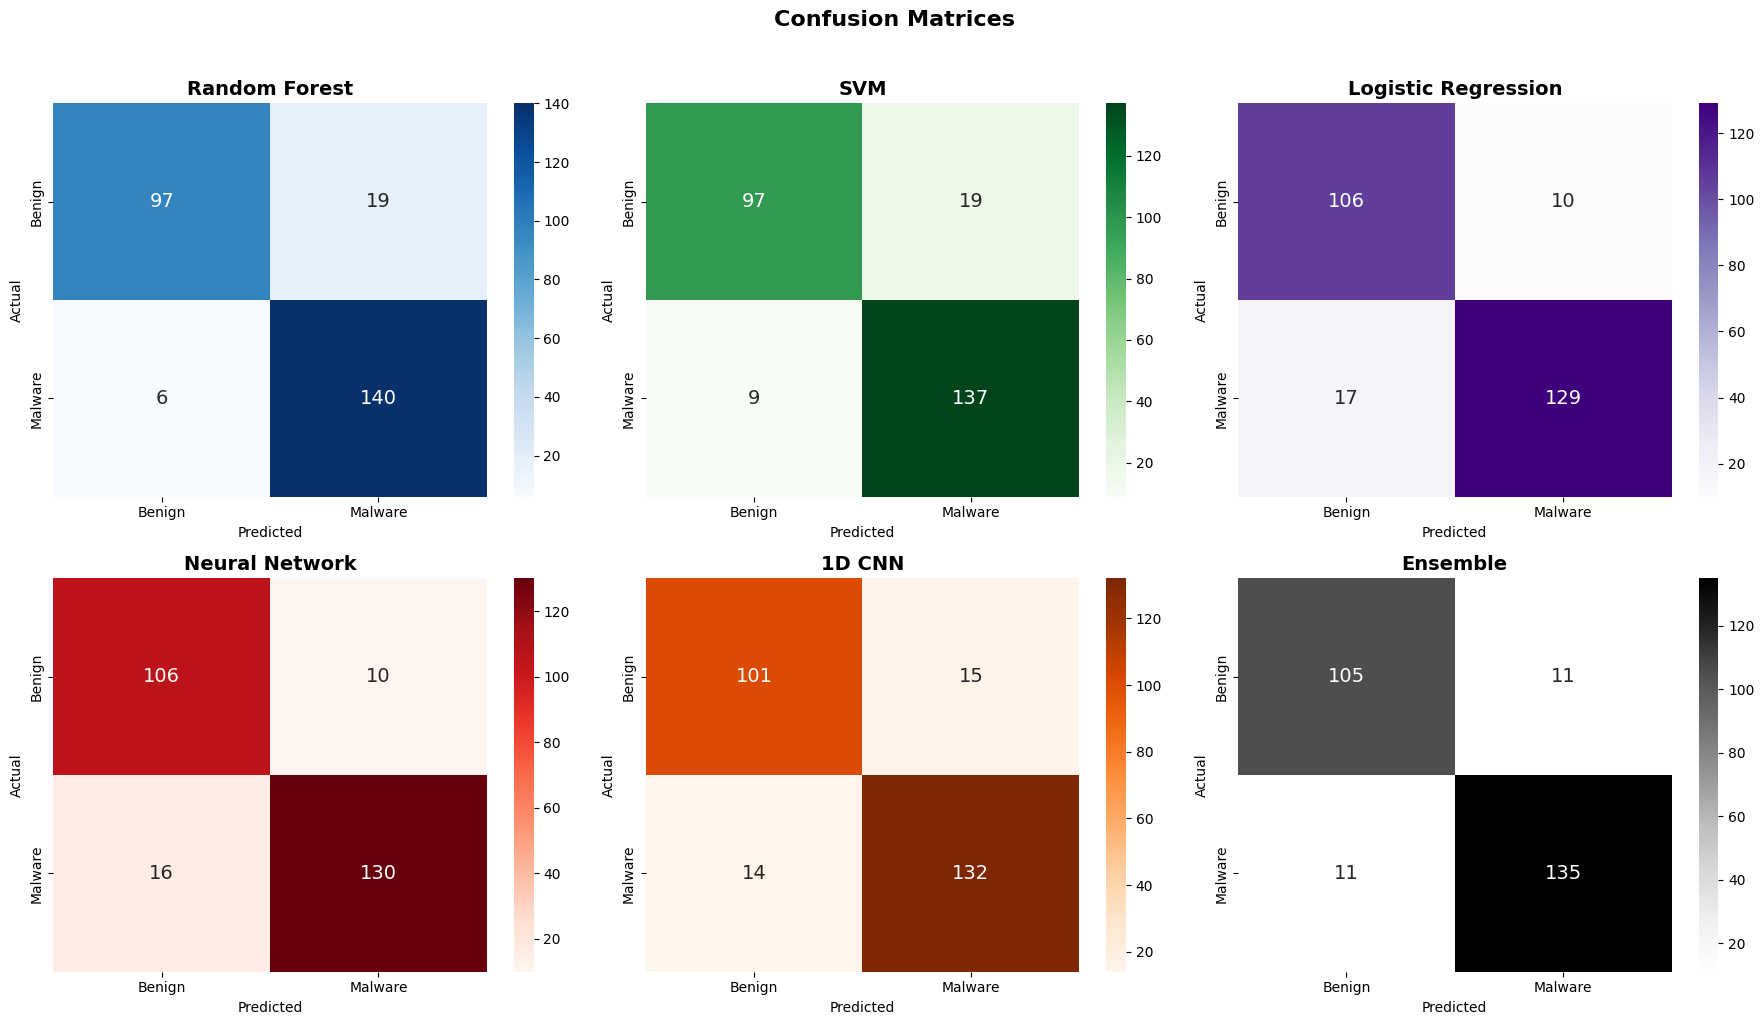

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['Blues', 'Greens', 'Purples', 'Reds', 'Oranges', 'Greys']
for i, (name, cmap) in enumerate(zip(model_names, colors)):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes.flatten()[i],
        xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'],
        annot_kws={'size': 14})
    axes.flatten()[i].set_title(name, fontsize=14, fontweight='bold')
    axes.flatten()[i].set_ylabel('Actual')
    axes.flatten()[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Bar Chart

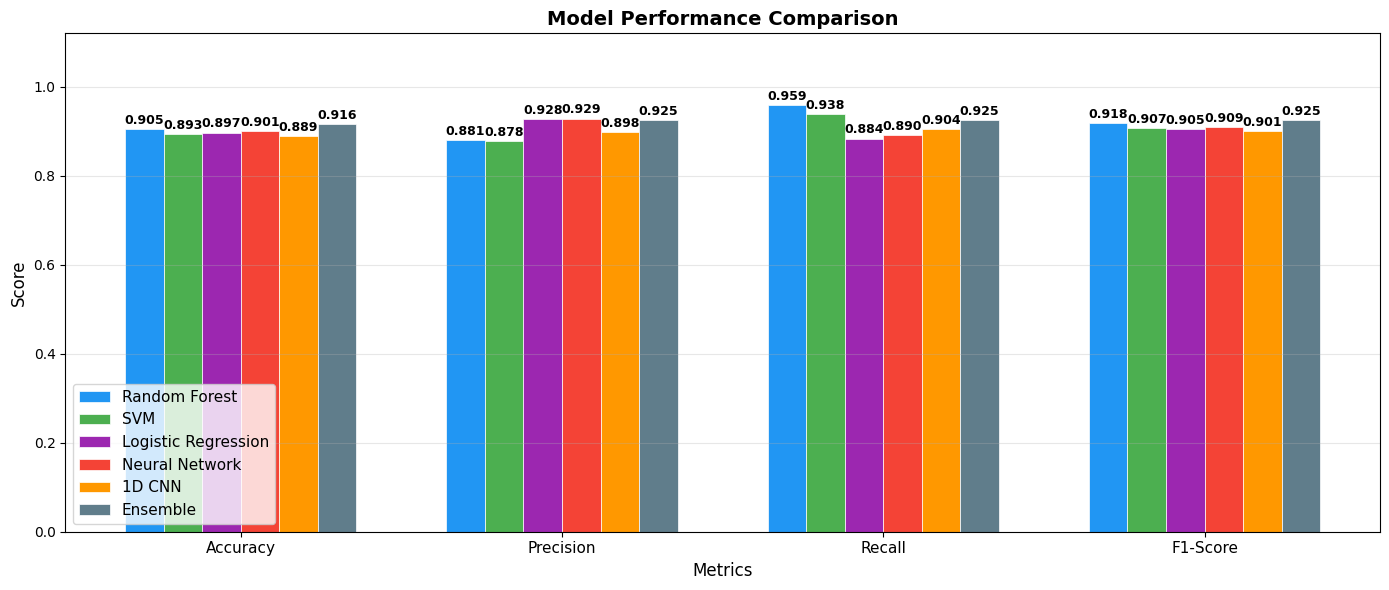

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.12
bar_colors = ['#2196F3', '#4CAF50', '#9C27B0', '#F44336', '#FF9800', '#607D8B']
fig, ax = plt.subplots(figsize=(14, 6))
for i, j in enumerate(model_names):
    values = [results[j][m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=j,
        color=bar_colors[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + 2.5 * width)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Final

In [ ]:
df.to_csv('Malware_Analysis_Cleaned.csv', index=False)
print('Saved to Dataset/Malware_Analysis_Cleaned.csv')
best = max(results, key=lambda k: results[k]['F1-Score'])
print(f'Best Model: {best} (F1={results[best]["F1-Score"]:.4f}, Acc={results[best]["Accuracy"]:.4f})')

Saved to Dataset/Malware_Analysis_Cleaned.csv
Best Model: Ensemble (F1=0.9247, Acc=0.9160)


Probability predictions collected from all models.


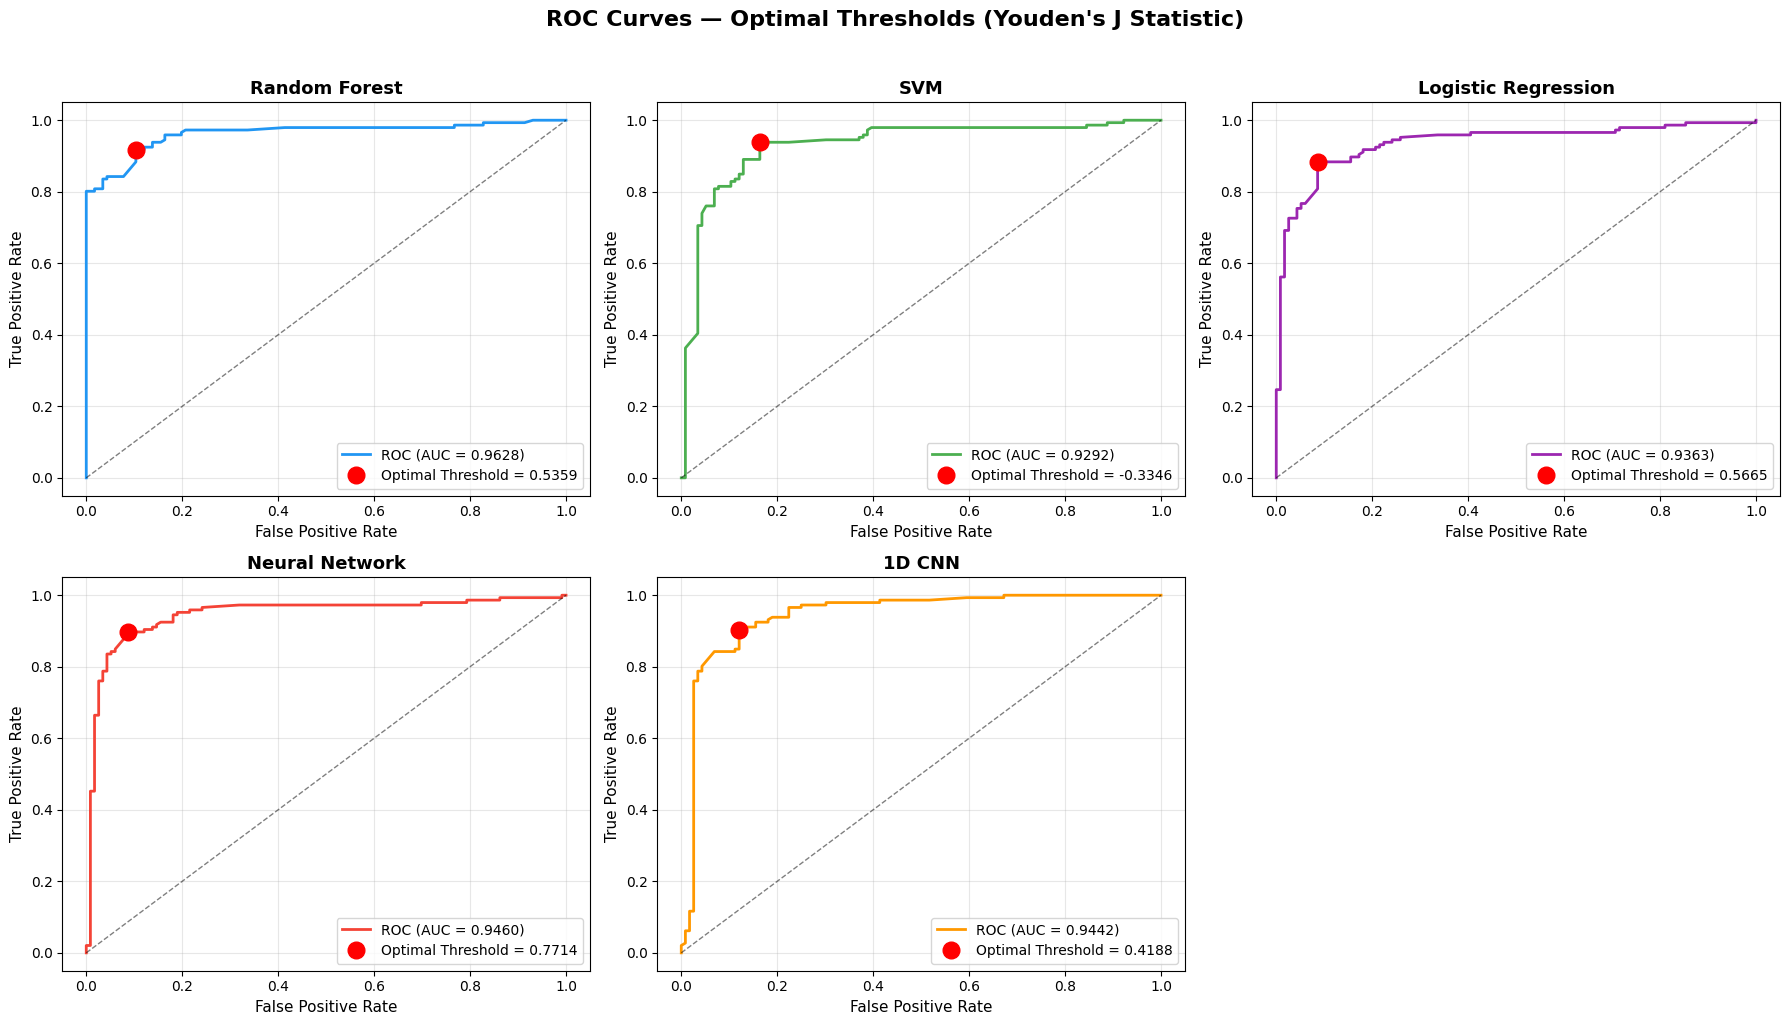


  ROC Curve Analysis — Optimal Thresholds (Youden's J)
  Random Forest              AUC=0.9628  Threshold=0.5359
  SVM                        AUC=0.9292  Threshold=-0.3346
  Logistic Regression        AUC=0.9363  Threshold=0.5665
  Neural Network             AUC=0.9460  Threshold=0.7714
  1D CNN                     AUC=0.9442  Threshold=0.4188


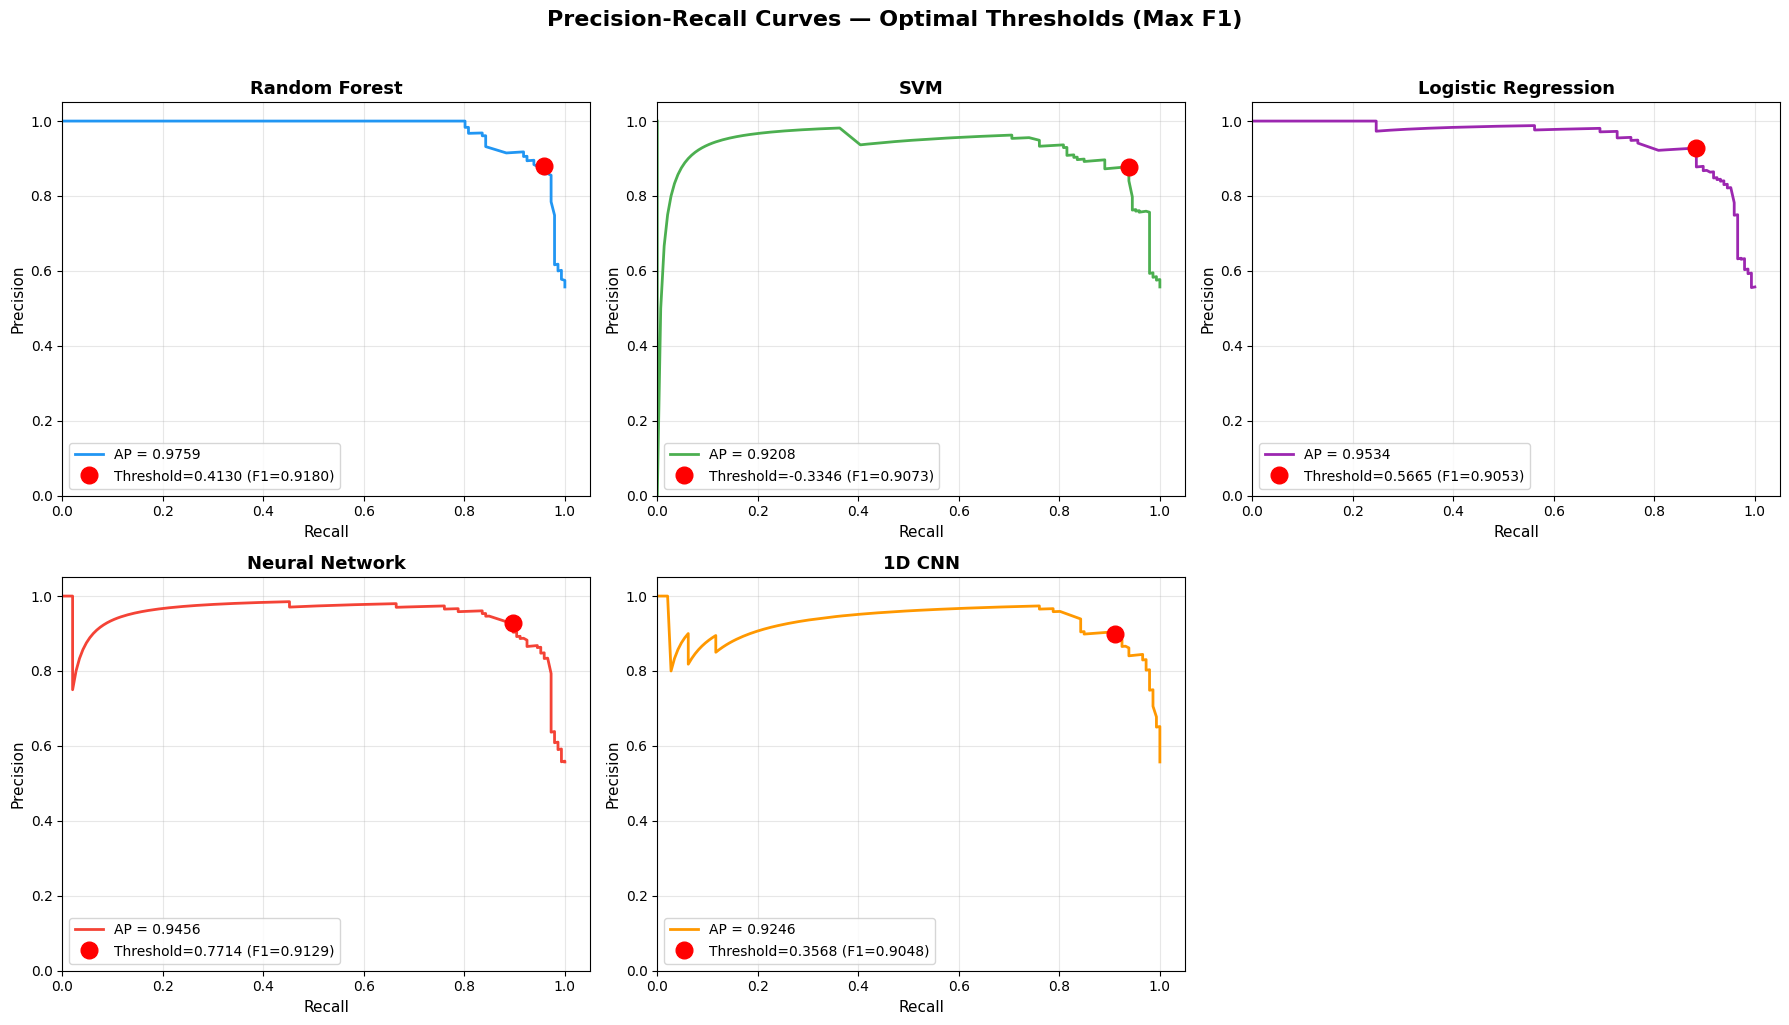


  Precision-Recall Analysis — Optimal Thresholds (Max F1)
  Random Forest              AP=0.9759  Threshold=0.4130  F1=0.9180
  SVM                        AP=0.9208  Threshold=-0.3346  F1=0.9073
  Logistic Regression        AP=0.9534  Threshold=0.5665  F1=0.9053
  Neural Network             AP=0.9456  Threshold=0.7714  F1=0.9129
  1D CNN                     AP=0.9246  Threshold=0.3568  F1=0.9048

  THRESHOLD COMPARISON: Default (0.5) vs ROC vs PR
  Model                        Default    ROC (J)    PR (F1)
----------------------------------------------------------------------
  Random Forest                 0.5000     0.5359     0.4130
  SVM                           0.0000    -0.3346    -0.3346
  Logistic Regression           0.5000     0.5665     0.5665
  Neural Network                0.5000     0.7714     0.7714
  1D CNN                        0.5000     0.4188     0.3568

  RE-EVALUATION WITH OPTIMAL THRESHOLDS

  Model                     |   Default F1 |       ROC F1 |        PR

In [ ]:
"""
Threshold Analysis Using ROC Curve and Precision-Recall Curve
=============================================================
Add these cells to your notebook AFTER all 5 models are trained
but BEFORE the Ensemble section.

This code:
1. Gets probability predictions from all models
2. Plots ROC curves & finds optimal threshold (Youden's J statistic)
3. Plots PR curves & finds optimal threshold (max F1)
4. Re-evaluates all models using optimal thresholds
5. Compares default (0.5) vs optimal threshold performance
"""

# ============================================================
# CELL 1: Imports & Get Probability Predictions
# ============================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# Get probability predictions from all models
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# SVM: use decision_function (raw scores, not probabilities)
# To get true probabilities, retrain with probability=True:
#   svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
# For now, using decision_function works fine with ROC/PR curves
svm_scores = svm_model.decision_function(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
nn_prob = nn_model.predict_proba(X_test_scaled)[:, 1]
# cnn_prob already exists from training

print('Probability predictions collected from all models.')

# ============================================================
# CELL 2: ROC Curve Analysis — Find Optimal Threshold
# ============================================================
model_probs = {
    'Random Forest': rf_prob,
    'SVM': svm_scores,
    'Logistic Regression': lr_prob,
    'Neural Network': nn_prob,
    '1D CNN': cnn_prob,
}

roc_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#2196F3', '#4CAF50', '#9C27B0', '#F44336', '#FF9800']

for i, (name, probs) in enumerate(model_probs.items()):
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    # Youden's J statistic: optimal point = max(TPR - FPR)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]

    roc_results[name] = {
        'auc': roc_auc,
        'optimal_threshold': optimal_threshold,
        'optimal_tpr': tpr[optimal_idx],
        'optimal_fpr': fpr[optimal_idx],
    }

    ax = axes.flatten()[i]
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    ax.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=12,
            label=f'Optimal Threshold = {optimal_threshold:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

# Hide the 6th subplot
axes.flatten()[5].set_visible(False)

plt.suptitle("ROC Curves — Optimal Thresholds (Youden's J Statistic)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print ROC results
print('\n' + '='*60)
print('  ROC Curve Analysis — Optimal Thresholds (Youden\'s J)')
print('='*60)
for name, res in roc_results.items():
    print(f'  {name:25s}  AUC={res["auc"]:.4f}  Threshold={res["optimal_threshold"]:.4f}')
print('='*60)


# ============================================================
# CELL 3: Precision-Recall Curve — Find Optimal Threshold
# ============================================================
pr_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, probs) in enumerate(model_probs.items()):
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)

    # Find threshold that maximizes F1 = 2*P*R / (P+R)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]

    pr_results[name] = {
        'ap': ap,
        'optimal_threshold': optimal_threshold,
        'optimal_f1': optimal_f1,
        'optimal_precision': precision[optimal_idx],
        'optimal_recall': recall[optimal_idx],
    }

    ax = axes.flatten()[i]
    ax.plot(recall, precision, color=colors[i], lw=2, label=f'AP = {ap:.4f}')
    ax.plot(recall[optimal_idx], precision[optimal_idx], 'ro', markersize=12,
            label=f'Threshold={optimal_threshold:.4f} (F1={optimal_f1:.4f})')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1.05])
    ax.set_ylim([0, 1.05])

axes.flatten()[5].set_visible(False)

plt.suptitle('Precision-Recall Curves — Optimal Thresholds (Max F1)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print PR results
print('\n' + '='*60)
print('  Precision-Recall Analysis — Optimal Thresholds (Max F1)')
print('='*60)
for name, res in pr_results.items():
    print(f'  {name:25s}  AP={res["ap"]:.4f}  Threshold={res["optimal_threshold"]:.4f}  F1={res["optimal_f1"]:.4f}')
print('='*60)


# ============================================================
# CELL 4: Compare Default (0.5) vs ROC vs PR Thresholds
# ============================================================
print('\n' + '='*70)
print('  THRESHOLD COMPARISON: Default (0.5) vs ROC vs PR')
print('='*70)
print(f'  {"Model":25s} {"Default":>10s} {"ROC (J)":>10s} {"PR (F1)":>10s}')
print('-'*70)
for name in model_probs:
    default = 0.5 if name != 'SVM' else 0.0  # SVM decision_function uses 0 as default
    roc_t = roc_results[name]['optimal_threshold']
    pr_t = pr_results[name]['optimal_threshold']
    print(f'  {name:25s} {default:>10.4f} {roc_t:>10.4f} {pr_t:>10.4f}')
print('='*70)


# ============================================================
# CELL 5: Re-evaluate models with optimal thresholds
# ============================================================
print('\n' + '='*70)
print('  RE-EVALUATION WITH OPTIMAL THRESHOLDS')
print('='*70)

optimal_results = {}

for name, probs in model_probs.items():
    roc_thresh = roc_results[name]['optimal_threshold']
    pr_thresh = pr_results[name]['optimal_threshold']

    # Predictions with ROC optimal threshold
    roc_pred = (probs >= roc_thresh).astype(int)
    roc_f1 = f1_score(y_test, roc_pred)
    roc_acc = accuracy_score(y_test, roc_pred)

    # Predictions with PR optimal threshold
    pr_pred = (probs >= pr_thresh).astype(int)
    pr_f1 = f1_score(y_test, pr_pred)
    pr_acc = accuracy_score(y_test, pr_pred)

    # Default threshold predictions (already computed)
    if name == 'SVM':
        default_pred = svm_pred
    elif name == 'Random Forest':
        default_pred = rf_pred
    elif name == 'Logistic Regression':
        default_pred = lr_pred
    elif name == 'Neural Network':
        default_pred = nn_pred
    elif name == '1D CNN':
        default_pred = cnn_pred

    default_f1 = f1_score(y_test, default_pred)
    default_acc = accuracy_score(y_test, default_pred)

    optimal_results[name] = {
        'default_f1': default_f1, 'default_acc': default_acc,
        'roc_f1': roc_f1, 'roc_acc': roc_acc, 'roc_thresh': roc_thresh,
        'pr_f1': pr_f1, 'pr_acc': pr_acc, 'pr_thresh': pr_thresh,
    }

# Print comparison table
print(f'\n  {"Model":25s} | {"Default F1":>12s} | {"ROC F1":>12s} | {"PR F1":>12s} | {"Best Method":>12s}')
print('-'*90)
for name, res in optimal_results.items():
    best = 'Default'
    best_f1 = res['default_f1']
    if res['roc_f1'] > best_f1:
        best = 'ROC'
        best_f1 = res['roc_f1']
    if res['pr_f1'] > best_f1:
        best = 'PR'

    print(f'  {name:25s} | {res["default_f1"]:>12.4f} | {res["roc_f1"]:>12.4f} | {res["pr_f1"]:>12.4f} | {best:>12s}')
print('='*90)

print(f'\n  {"Model":25s} | {"Default Acc":>12s} | {"ROC Acc":>12s} | {"PR Acc":>12s}')
print('-'*75)
for name, res in optimal_results.items():
    print(f'  {name:25s} | {res["default_acc"]:>12.4f} | {res["roc_acc"]:>12.4f} | {res["pr_acc"]:>12.4f}')
print('='*75)


# ============================================================
# CELL 6: Final Summary — Recommended Thresholds
# ============================================================
print('\n' + '='*70)
print('  RECOMMENDED THRESHOLDS')
print('='*70)
for name, res in optimal_results.items():
    scores = {
        'Default (0.5)': res['default_f1'],
        f'ROC ({res["roc_thresh"]:.4f})': res['roc_f1'],
        f'PR ({res["pr_thresh"]:.4f})': res['pr_f1'],
    }
    best_method = max(scores, key=scores.get)
    best_f1 = scores[best_method]
    print(f'  {name:25s} → {best_method} → F1={best_f1:.4f}')
print('='*70)


In [ ]:
"""
Score Threshold Justification
=============================
This script finds the OPTIMAL Score threshold for creating
the binary label (Benign vs Malware) by:

1. Visualizing the Score distribution
2. Testing multiple thresholds with Cross-Validation
3. Using ROC Curve on the Score column
4. Using Precision-Recall Curve on the Score column
5. Comparing all methods to pick the best threshold

Add these as new cells at the TOP of your notebook,
BEFORE the label creation step.
"""

# ============================================================
# CELL 1: Score Distribution Analysis
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score
)

df_raw = pd.read_csv('Malware_Analysis.csv')

# Plot Score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df_raw['Score'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Distribution of Malware Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=5.0, color='red', linestyle='--', linewidth=2, label='Threshold = 5.0')
axes[0].axvline(x=6.5, color='green', linestyle='--', linewidth=2, label='Threshold = 6.5')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df_raw['Score'], vert=True)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Score Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Score Statistics:')
print(df_raw['Score'].describe())
print(f'\nMedian Score: {df_raw["Score"].median()}')
print(f'Mean Score:   {df_raw["Score"].mean():.2f}')


# ============================================================
# CELL 2: Test Multiple Score Thresholds with Cross-Validation
# ============================================================
# Prepare features (same preprocessing as your notebook)
columns_to_drop = [
    'pid', 'info_id',
    'API_GetAdaptersInfo', 'API_InternetSetStatusCallback',
    'API_SetFileInformationByHandle', 'API_getaddrinfo',
    'API_RtlDecompressBuffer', 'API_DnsQuery_A',
    'API_Module32NextW', 'API_ControlService',
    'API_JsGlobalObjectDefaultEvalHelper',
    'API_Thread32Next', 'API_Thread32First',
    'ttp_T1045_short', 'ttp_T1045_long',
    'ttp_T1082_short', 'ttp_T1082_long',
    'ttp_T1158_short', 'ttp_T1158_long',
    'description_y', 'description_x', 'references'
]

# Keep Score column for threshold testing
df_temp = df_raw.drop(columns=columns_to_drop, errors='ignore')

# Encode categoricals
cat_cols = df_temp.select_dtypes(include=['object']).columns.tolist()
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    df_temp[c] = df_temp[c].fillna('missing')
    df_temp[c] = le.fit_transform(df_temp[c])
    le_dict[c] = le
df_temp = df_temp.fillna(0)

# Test thresholds from 1.0 to 9.0
thresholds = np.arange(1.0, 9.5, 0.5)
cv_results = []

print('Testing Score thresholds with 5-Fold Cross-Validation...')
print(f'{"Threshold":>10s} | {"Accuracy":>10s} | {"F1-Score":>10s} | {"Malware%":>10s} | {"Samples":>10s}')
print('-' * 65)

for thresh in thresholds:
    # Create label with this threshold
    y = (df_temp['Score'] >= thresh).astype(int)
    X = df_temp.drop(columns=['Score'])

    malware_pct = y.mean() * 100

    # Skip if too imbalanced (< 10% or > 90% malware)
    if malware_pct < 10 or malware_pct > 90:
        print(f'{thresh:>10.1f} | {"SKIPPED - too imbalanced":>40s}')
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5-Fold CV with Random Forest
    rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    acc_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring='f1')

    cv_results.append({
        'threshold': thresh,
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std': acc_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'malware_pct': malware_pct,
        'n_malware': y.sum(),
        'n_benign': (1-y).sum(),
    })

    print(f'{thresh:>10.1f} | {acc_scores.mean():>10.4f} | {f1_scores.mean():>10.4f} | {malware_pct:>9.1f}% | {len(y):>10d}')

print('-' * 65)

# Find best threshold
cv_df = pd.DataFrame(cv_results)
best_by_f1 = cv_df.loc[cv_df['f1_mean'].idxmax()]
best_by_acc = cv_df.loc[cv_df['accuracy_mean'].idxmax()]

print(f'\n>> Best threshold by F1-Score:  {best_by_f1["threshold"]:.1f} (F1={best_by_f1["f1_mean"]:.4f} +/- {best_by_f1["f1_std"]:.4f})')
print(f'>> Best threshold by Accuracy: {best_by_acc["threshold"]:.1f} (Acc={best_by_acc["accuracy_mean"]:.4f} +/- {best_by_acc["accuracy_std"]:.4f})')


# ============================================================
# CELL 3: Plot Threshold vs Performance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 Score plot
axes[0].plot(cv_df['threshold'], cv_df['f1_mean'], 'bo-', linewidth=2, markersize=8, label='F1-Score')
axes[0].fill_between(cv_df['threshold'],
                      cv_df['f1_mean'] - cv_df['f1_std'],
                      cv_df['f1_mean'] + cv_df['f1_std'],
                      alpha=0.2, color='blue')
axes[0].axvline(x=best_by_f1['threshold'], color='red', linestyle='--', linewidth=2,
                label=f'Best = {best_by_f1["threshold"]:.1f}')
axes[0].set_xlabel('Score Threshold', fontsize=12)
axes[0].set_ylabel('F1-Score (5-Fold CV)', fontsize=12)
axes[0].set_title('F1-Score vs Score Threshold', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(cv_df['threshold'], cv_df['accuracy_mean'], 'go-', linewidth=2, markersize=8, label='Accuracy')
axes[1].fill_between(cv_df['threshold'],
                      cv_df['accuracy_mean'] - cv_df['accuracy_std'],
                      cv_df['accuracy_mean'] + cv_df['accuracy_std'],
                      alpha=0.2, color='green')
axes[1].axvline(x=best_by_acc['threshold'], color='red', linestyle='--', linewidth=2,
                label=f'Best = {best_by_acc["threshold"]:.1f}')
axes[1].set_xlabel('Score Threshold', fontsize=12)
axes[1].set_ylabel('Accuracy (5-Fold CV)', fontsize=12)
axes[1].set_title('Accuracy vs Score Threshold', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# CELL 4: ROC Curve on Score Column
# ============================================================
# Treat Score as a "diagnostic test" for malware detection
# Use a reference label from the best-performing threshold
best_thresh = best_by_f1['threshold']
reference_label = (df_temp['Score'] >= best_thresh).astype(int)

# Normalize Score to [0, 1] for ROC analysis
score_normalized = df_temp['Score'] / df_temp['Score'].max()

fpr, tpr, roc_thresholds = roc_curve(reference_label, score_normalized)
roc_auc = auc(fpr, tpr)

# Youden's J
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_normalized = roc_thresholds[optimal_idx]
optimal_score = optimal_normalized * df_temp['Score'].max()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=15,
             label=f'Optimal Score = {optimal_score:.1f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Score as Diagnostic Test', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(reference_label, score_normalized)
f1_pr = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
pr_optimal_idx = np.argmax(f1_pr)
pr_optimal_score = pr_thresholds[pr_optimal_idx] * df_temp['Score'].max()

axes[1].plot(recall, precision, 'g-', linewidth=2, label='PR Curve')
axes[1].plot(recall[pr_optimal_idx], precision[pr_optimal_idx], 'ro', markersize=15,
             label=f'Optimal Score = {pr_optimal_score:.1f}')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve — Score as Diagnostic Test', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nROC Analysis — Optimal Score Threshold: {optimal_score:.2f}')
print(f'PR  Analysis — Optimal Score Threshold: {pr_optimal_score:.2f}')


# ============================================================
# CELL 5: Final Summary & Recommendation
# ============================================================
print('\n' + '='*70)
print('  SCORE THRESHOLD ANALYSIS — FINAL SUMMARY')
print('='*70)
print(f'\n  Method 1: Cross-Validation (Best F1)     → Threshold = {best_by_f1["threshold"]:.1f}')
print(f'  Method 2: Cross-Validation (Best Acc)     → Threshold = {best_by_acc["threshold"]:.1f}')
print(f'  Method 3: ROC Curve (Youden\'s J)          → Threshold = {optimal_score:.1f}')
print(f'  Method 4: Precision-Recall (Max F1)        → Threshold = {pr_optimal_score:.1f}')
print(f'\n  Class distribution at each threshold:')
print(f'  {"Threshold":>10s} | {"Benign":>8s} | {"Malware":>8s} | {"Ratio":>8s}')
print(f'  {"-"*45}')
for _, row in cv_df.iterrows():
    print(f'  {row["threshold"]:>10.1f} | {int(row["n_benign"]):>8d} | {int(row["n_malware"]):>8d} | {row["malware_pct"]:>7.1f}%')
print('='*70)

# Final recommendation
print(f'\n  ✅ RECOMMENDED THRESHOLD: {best_by_f1["threshold"]:.1f}')
print(f'     F1-Score: {best_by_f1["f1_mean"]:.4f} ± {best_by_f1["f1_std"]:.4f}')
print(f'     Accuracy: {best_by_f1["accuracy_mean"]:.4f} ± {best_by_f1["accuracy_std"]:.4f}')
print(f'\n  Use this in your notebook:')
print(f'     df["label"] = (df["Score"] >= {best_by_f1["threshold"]:.1f}).astype(int)')
print('='*70)
